In [15]:
# Importations 
import  numpy  as  np 
import  matplotlib.pyplot  as  plt

In [16]:
# Load the data
raw_ecg = np.loadtxt('../data/ECGu.txt')

# Look at the data
print(raw_ecg)
print(raw_ecg.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


In [17]:
# Conversion en mV (ou microvolts selon l'échelle)
ecg_mv = (raw_ecg * 1.024) / 1000

# Vérification du résultat
print(ecg_mv)

[[-0.2816   -0.121856 -0.121856]
 [-0.2816   -0.121856 -0.121856]
 [-0.2816   -0.120832 -0.123904]
 ...
 [-0.004096 -0.084992  0.021504]
 [-0.009216 -0.090112  0.031744]
 [-0.016384 -0.098304  0.033792]]


In [18]:
# Create the time vector in seconds (sampling frequency = 1000 Hz)
num_samples = len(ecg_mv)
time = np.arange(0, num_samples) / 1000

# Inspect the time vector
print(time)
print(f"Total duration: {time[-1]} seconds")


[0.000e+00 1.000e-03 2.000e-03 ... 6.497e+00 6.498e+00 6.499e+00]
Total duration: 6.499 seconds


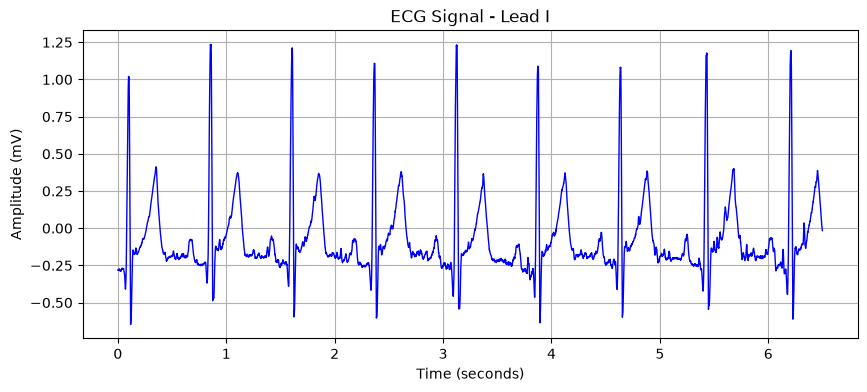

In [19]:
import matplotlib.pyplot as plt

# 4.6 Plotting the ECG data (Lead I)
plt.figure(figsize=(10, 4))
plt.plot(time, ecg_mv[:, 0], color='blue', linewidth=1)

# Formatting the plot
plt.title("ECG Signal - Lead I")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)

# Display the plot
plt.show()

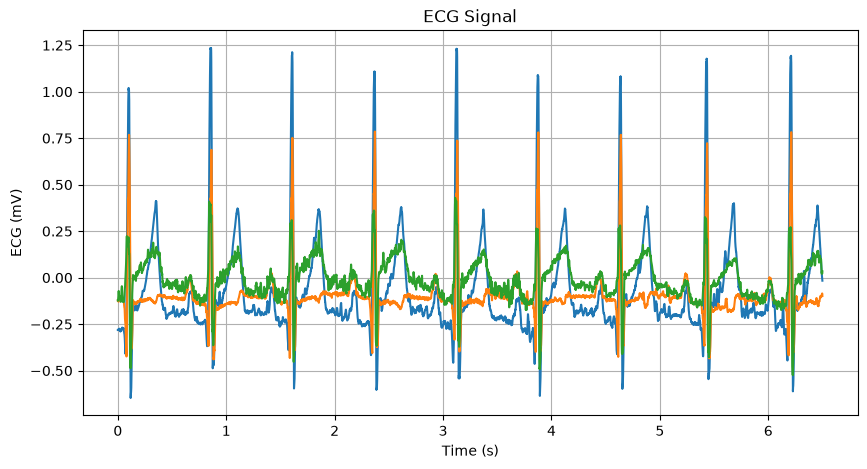

In [20]:
import matplotlib.pyplot as plt

# 4.6 Plotting all 3 leads
plt.figure(figsize=(10, 5))

# Plot Lead I, Lead II, and Lead III
plt.plot(time, ecg_mv[:, 0], label="Lead I")
plt.plot(time, ecg_mv[:, 1], label="Lead II")
plt.plot(time, ecg_mv[:, 2], label="Lead III")

# Formatting
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("ECG (mV)")
plt.grid(True)

plt.show()

In [21]:
def process_ecg_data(raw_data, fs=1000, conversion_factor=1.024):
    """
    Converts raw ECG data to mV and generates the corresponding time vector.
    
    Parameters:
        raw_data (numpy.ndarray): Raw ECG signal matrix.
        fs (int): Sampling frequency in Hz (default: 1000 Hz).
        conversion_factor (float): Conversion unit (default: 1.024 uV per unit).
        
    Returns:
        tuple: (ecg_mv, time) converted ECG matrix in mV and time array in seconds.
    """
    # Convert raw data to mV (1 unit = 1.024 uV, then divide by 1000 to get mV)
    ecg_mv = (raw_data * conversion_factor) / 1000
    
    # Generate time vector in seconds
    num_samples = len(ecg_mv)
    time = np.arange(0, num_samples) / fs
    
    return ecg_mv, time

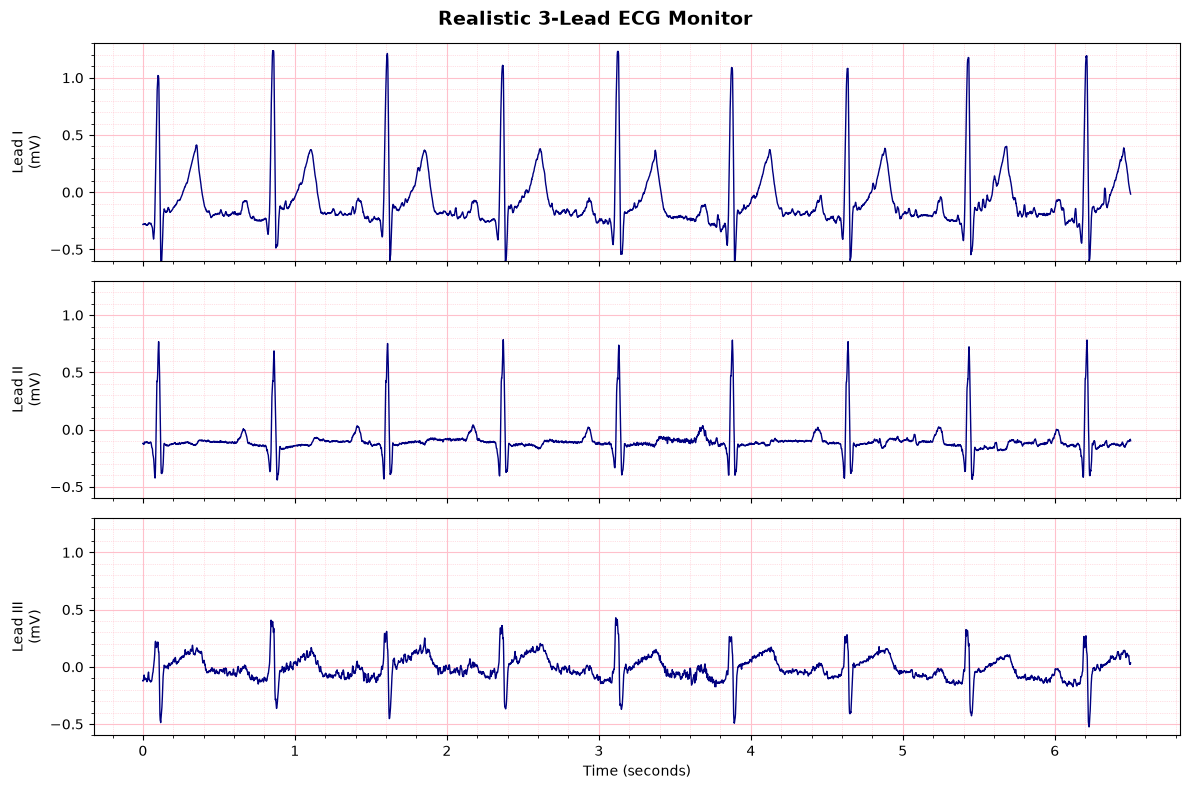

In [22]:
import matplotlib.pyplot as plt

# Apply processing function
ecg_mv, time = process_ecg_data(raw_ecg)

# Create 3 stacked subplots (one for each lead)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

leads_names = ["Lead I", "Lead II", "Lead III"]
colors = ['green', 'green', 'green']  # Moniteur médical style vert/noir ou ligne sombre sur fond rose

for i in range(3):
    ax = axes[i]
    ax.plot(time, ecg_mv[:, i], color='navy', linewidth=1)
    ax.set_ylabel(f"{leads_names[i]}\n(mV)")
    
    # Grid styling to mimic ECG paper (major and minor grids)
    ax.grid(True, which='major', color='pink', linestyle='-', linewidth=0.8)
    ax.minorticks_on()
    ax.grid(True, which='minor', color='pink', linestyle=':', linewidth=0.5)
    
    # Set y limits for consistency
    ax.set_ylim(-0.6, 1.3)

axes[2].set_xlabel("Time (seconds)")
fig.suptitle("Realistic 3-Lead ECG Monitor", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()